## Imports and reproducibility

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
)

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Paths and evaluation configuration

In [2]:
DATA_PATH = Path("input/wine_reviews_cleaned.csv")
TRAIN_PATH = Path("train1.csv")
TEST_PATH = Path("test1.csv")

MODEL_PATH = Path("best_mlp_tfidf.pth")
VECTORIZER_PATH = Path("tfidf_vectorizer.joblib")

OUTPUT_DIR = Path("evaluation_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REBUILD_VECTORIZER_FROM_TRAIN = True
BATCH_SIZE = 256

required = [DATA_PATH, TRAIN_PATH, TEST_PATH, MODEL_PATH]
missing = [str(p) for p in required if not p.exists()]

if missing:
    raise FileNotFoundError(
        "Missing required file(s):\n- " + "\n- ".join(missing)
    )

print("Required files found.")

Required files found.


## Reconstruct the country label mapping

In [3]:
source_df = pd.read_csv(DATA_PATH)

needed_columns = {"clean_description", "country"}
missing_columns = needed_columns - set(source_df.columns)
if missing_columns:
    raise ValueError(f"Missing columns in {DATA_PATH}: {sorted(missing_columns)}")

label_df = source_df[["clean_description", "country"]].copy()
label_df = label_df[
    label_df["clean_description"].notna() &
    label_df["country"].notna()
]
label_df = label_df[
    label_df.groupby("country")["country"].transform("count") >= 5
]

label_encoder = LabelEncoder()
label_encoder.fit(label_df["country"])

class_names = label_encoder.classes_
n_classes = len(class_names)

print(f"Number of classes: {n_classes}")
print("Countries:")
print(list(class_names))

Number of classes: 38
Countries:
['Argentina', 'Australia', 'Austria', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'Croatia', 'Cyprus', 'Czech Republic', 'England', 'France', 'Georgia', 'Germany', 'Greece', 'Hungary', 'India', 'Israel', 'Italy', 'Lebanon', 'Luxembourg', 'Macedonia', 'Mexico', 'Moldova', 'Morocco', 'New Zealand', 'Peru', 'Portugal', 'Romania', 'Serbia', 'Slovenia', 'South Africa', 'Spain', 'Switzerland', 'Turkey', 'US', 'Ukraine', 'Uruguay']


## Load the saved train/test splits

In [ ]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

required_split_columns = {"clean_description", "country"}

for name, frame in [("train", train_df), ("test", test_df)]:
    missing = required_split_columns - set(frame.columns)
    if missing:
        raise ValueError(f"{name} split is missing columns: {sorted(missing)}")

train_df = train_df.dropna(subset=["clean_description", "state"]).copy()
test_df = test_df.dropna(subset=["clean_description", "state"]).copy()

train_df["state"] = train_df["state"].astype(int)
test_df["state"] = test_df["state"].astype(int)

X_train = train_df["clean_description"].astype(str)
X_test = test_df["clean_description"].astype(str)
y_train = train_df["state"].to_numpy()
y_test = test_df["state"].to_numpy()

if y_test.min() < 0 or y_test.max() >= n_classes:
    raise ValueError(
        f"Test labels range from {y_test.min()} to {y_test.max()}, "
        f"but the reconstructed label encoder has {n_classes} classes."
    )

print(f"Training rows: {len(train_df):,}")
print(f"Test rows:     {len(test_df):,}")

Training rows: 90,930
Test rows:     19,486


## Load or reconstruct the final TF-IDF vectorizer

In [5]:
FINAL_TFIDF_PARAMS = {
    "max_features": 5000,
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.95,
    "sublinear_tf": True,
}

if REBUILD_VECTORIZER_FROM_TRAIN:
    vectorizer = TfidfVectorizer(**FINAL_TFIDF_PARAMS)
    vectorizer.fit(X_train)
    print("Rebuilt the final TF-IDF vectorizer from train1.csv.")
else:
    if not VECTORIZER_PATH.exists():
        raise FileNotFoundError(
            f"{VECTORIZER_PATH} was not found. "
            "Set REBUILD_VECTORIZER_FROM_TRAIN=True."
        )
    vectorizer = joblib.load(VECTORIZER_PATH)
    print(f"Loaded vectorizer from {VECTORIZER_PATH}.")

X_test_tfidf = vectorizer.transform(X_test)

print(f"TF-IDF test matrix shape: {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")

Rebuilt the final TF-IDF vectorizer from train1.csv.
TF-IDF test matrix shape: (19486, 5000)
Vocabulary size: 5,000


## Recreate the MLP architecture and load the checkpoint

In [6]:
class MLPClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dims=(512, 256, 128),
        num_classes=38,
        dropout=0.4,
    ):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


checkpoint = torch.load(MODEL_PATH, map_location=device)

if not isinstance(checkpoint, dict) or "model_state_dict" not in checkpoint:
    raise ValueError(
        "Expected best_mlp_tfidf.pth to contain 'model_state_dict' "
        "and the saved Optuna parameters."
    )

best_params = checkpoint.get("best_params", {})
input_dim = int(checkpoint.get("input_dim", X_test_tfidf.shape[1]))

required_params = ["hidden_1", "hidden_2", "hidden_3", "dropout"]
missing_params = [p for p in required_params if p not in best_params]
if missing_params:
    raise KeyError(f"Checkpoint is missing best_params: {missing_params}")

hidden_dims = [
    int(best_params["hidden_1"]),
    int(best_params["hidden_2"]),
    int(best_params["hidden_3"]),
]
dropout = float(best_params["dropout"])

# Infer the output size directly from the final Linear layer in the checkpoint.
linear_weight_keys = [
    k for k, v in checkpoint["model_state_dict"].items()
    if k.endswith(".weight") and getattr(v, "ndim", 0) == 2
]
if not linear_weight_keys:
    raise ValueError("Could not infer the final output layer from the checkpoint.")

checkpoint_num_classes = int(
    checkpoint["model_state_dict"][linear_weight_keys[-1]].shape[0]
)

if checkpoint_num_classes != n_classes:
    raise ValueError(
        f"Checkpoint has {checkpoint_num_classes} outputs, but the reconstructed "
        f"label mapping contains {n_classes} classes."
    )

if X_test_tfidf.shape[1] != input_dim:
    raise ValueError(
        f"Feature dimension mismatch: vectorizer produced {X_test_tfidf.shape[1]} "
        f"features, checkpoint expects {input_dim}."
    )

model = MLPClassifier(
    input_dim=input_dim,
    hidden_dims=hidden_dims,
    num_classes=checkpoint_num_classes,
    dropout=dropout,
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Checkpoint loaded successfully.")
print(f"Input dimension: {input_dim}")
print(f"Hidden layers:   {hidden_dims}")
print(f"Dropout:         {dropout}")
print(f"Output classes:  {checkpoint_num_classes}")

if "best_f1" in checkpoint:
    print(f"Saved Optuna best validation F1: {checkpoint['best_f1']:.4f}")

Checkpoint loaded successfully.
Input dimension: 5000
Hidden layers:   [460, 184, 64]
Dropout:         0.12542334011440948
Output classes:  38
Saved Optuna best validation F1: 0.8170


## Build the test DataLoader

In [7]:
class SparseReviewDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = np.asarray(labels, dtype=np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        row = self.features[idx].toarray().ravel().astype(np.float32)
        return torch.from_numpy(row), torch.tensor(self.labels[idx], dtype=torch.long)


test_dataset = SparseReviewDataset(X_test_tfidf, y_test)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print(f"Test samples: {len(test_dataset):,}")
print(f"Test batches: {len(test_loader):,}")

Test samples: 19,486
Test batches: 77


## Run inference once

In [8]:
all_labels = []
all_preds = []
all_probs = []

model.eval()

with torch.inference_mode():
    for features, labels in test_loader:
        features = features.to(device)
        outputs = model(features)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)

        all_labels.append(labels.numpy())
        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

y_true = np.concatenate(all_labels)
y_pred = np.concatenate(all_preds)
y_prob = np.vstack(all_probs)

assert len(y_true) == len(test_df)
assert y_prob.shape == (len(test_df), n_classes)

print(f"Predictions generated for {len(y_true):,} test samples.")

Predictions generated for 19,486 test samples.


## Overall test metrics

Both **macro** and **weighted** averages are reported because the country classes are imbalanced.

In [9]:
metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision_macro": precision_score(
        y_true, y_pred, average="macro", zero_division=0
    ),
    "recall_macro": recall_score(
        y_true, y_pred, average="macro", zero_division=0
    ),
    "f1_macro": f1_score(
        y_true, y_pred, average="macro", zero_division=0
    ),
    "precision_weighted": precision_score(
        y_true, y_pred, average="weighted", zero_division=0
    ),
    "recall_weighted": recall_score(
        y_true, y_pred, average="weighted", zero_division=0
    ),
    "f1_weighted": f1_score(
        y_true, y_pred, average="weighted", zero_division=0
    ),
}

# AUC requires a class to have both positive and negative examples.
try:
    metrics["roc_auc_macro_ovr"] = roc_auc_score(
        y_true,
        y_prob,
        average="macro",
        multi_class="ovr",
        labels=np.arange(n_classes),
    )
    metrics["roc_auc_weighted_ovr"] = roc_auc_score(
        y_true,
        y_prob,
        average="weighted",
        multi_class="ovr",
        labels=np.arange(n_classes),
    )
except ValueError as exc:
    print(f"ROC-AUC could not be computed for every class: {exc}")
    metrics["roc_auc_macro_ovr"] = np.nan
    metrics["roc_auc_weighted_ovr"] = np.nan

metrics_df = (
    pd.DataFrame(
        {"metric": list(metrics.keys()), "value": list(metrics.values())}
    )
    .sort_values("metric")
    .reset_index(drop=True)
)

display(metrics_df.style.format({"value": "{:.4f}"}))

metrics_df.to_csv(OUTPUT_DIR / "overall_metrics.csv", index=False)

,metric,value
0,accuracy,0.8376
1,f1_macro,0.3614
2,f1_weighted,0.8367
3,precision_macro,0.3779
4,precision_weighted,0.8374
5,recall_macro,0.3612
6,recall_weighted,0.8376
7,roc_auc_macro_ovr,0.9433
8,roc_auc_weighted_ovr,0.9818


## Per-country classification report

In [10]:
report_dict = classification_report(
    y_true,
    y_pred,
    labels=np.arange(n_classes),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).T

country_report_df = report_df.loc[class_names].copy()
country_report_df.index.name = "country"
country_report_df = country_report_df.sort_values(
    ["f1-score", "support"],
    ascending=[True, False],
)

display(
    country_report_df.style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}",
    })
)

country_report_df.to_csv(OUTPUT_DIR / "per_country_classification_report.csv")

,precision,recall,f1-score,support
country,,,,
Slovenia,0.0000,0.0000,0.0000,13
Brazil,0.0000,0.0000,0.0000,8
Morocco,0.0000,0.0000,0.0000,4
Macedonia,0.0000,0.0000,0.0000,2
Peru,0.0000,0.0000,0.0000,2
Serbia,0.0000,0.0000,0.0000,2
Ukraine,0.0000,0.0000,0.0000,2
Cyprus,0.0000,0.0000,0.0000,1
India,0.0000,0.0000,0.0000,1


The NLP model achieved a strong overall **accuracy** of $83.76%$, with a **weighted F1-score** of $0.8367$. However, the much lower **macro F1-score** of $0.3614$ indicates uneven performance across countries. The model performed particularly well for highly represented countries such as Italy $(F1 = 0.9643)$, the US $(0.9397)$, and France $(0.8148)$, while several countries with few samples had **F1-scores** of $0$. This suggests that class imbalance significantly affected the model, making it more reliable for frequently represented countries than minority classes. Despite this, the high **weighted ROC-AUC** of $0.9818$ indicates strong overall ability to distinguish between country classes.

## Best- and worst-performing countries by F1

In [11]:
ranking_df = country_report_df.reset_index()[
    ["country", "precision", "recall", "f1-score", "support"]
]

print("Lowest F1 countries:")
display(ranking_df.head(10))

print("Highest F1 countries:")
display(ranking_df.tail(10).sort_values("f1-score", ascending=False))

Lowest F1 countries:


,country,precision,recall,f1-score,support
0,Slovenia,0.0,0.0,0.0,13.0
1,Brazil,0.0,0.0,0.0,8.0
2,Morocco,0.0,0.0,0.0,4.0
3,Macedonia,0.0,0.0,0.0,2.0
4,Peru,0.0,0.0,0.0,2.0
5,Serbia,0.0,0.0,0.0,2.0
6,Ukraine,0.0,0.0,0.0,2.0
7,Cyprus,0.0,0.0,0.0,1.0
8,India,0.0,0.0,0.0,1.0
9,Luxembourg,0.0,0.0,0.0,1.0


Highest F1 countries:


,country,precision,recall,f1-score,support
37,Italy,0.985053,0.944388,0.964292,2931.0
36,US,0.939809,0.939579,0.939694,8176.0
35,France,0.808012,0.821666,0.814782,3314.0
34,Germany,0.636364,0.796923,0.707650,325.0
33,Spain,0.661661,0.751254,0.703617,997.0
32,Austria,0.703390,0.661355,0.681725,502.0
30,Greece,0.595506,0.757143,0.666667,70.0
31,England,0.615385,0.727273,0.666667,11.0
29,New Zealand,0.562264,0.699531,0.623431,213.0
28,Portugal,0.612059,0.629977,0.620889,854.0


The highest **F1-scores** were achieved by Italy $(0.9643)$, the US $(0.9397)$, and France $(0.8148)$, which also had some of the largest numbers of samples. In contrast, countries such as Slovenia, Brazil, Morocco, and several other low-support classes had **F1-scores** of $0$, meaning the model failed to correctly classify them. This further highlights the effect of class imbalance, although countries such as England achieved a relatively high **F1-score** $(0.6667)$ despite having only $11$ samples, suggesting that sample size alone does not determine classification performance.

## Confusion matrix — raw counts

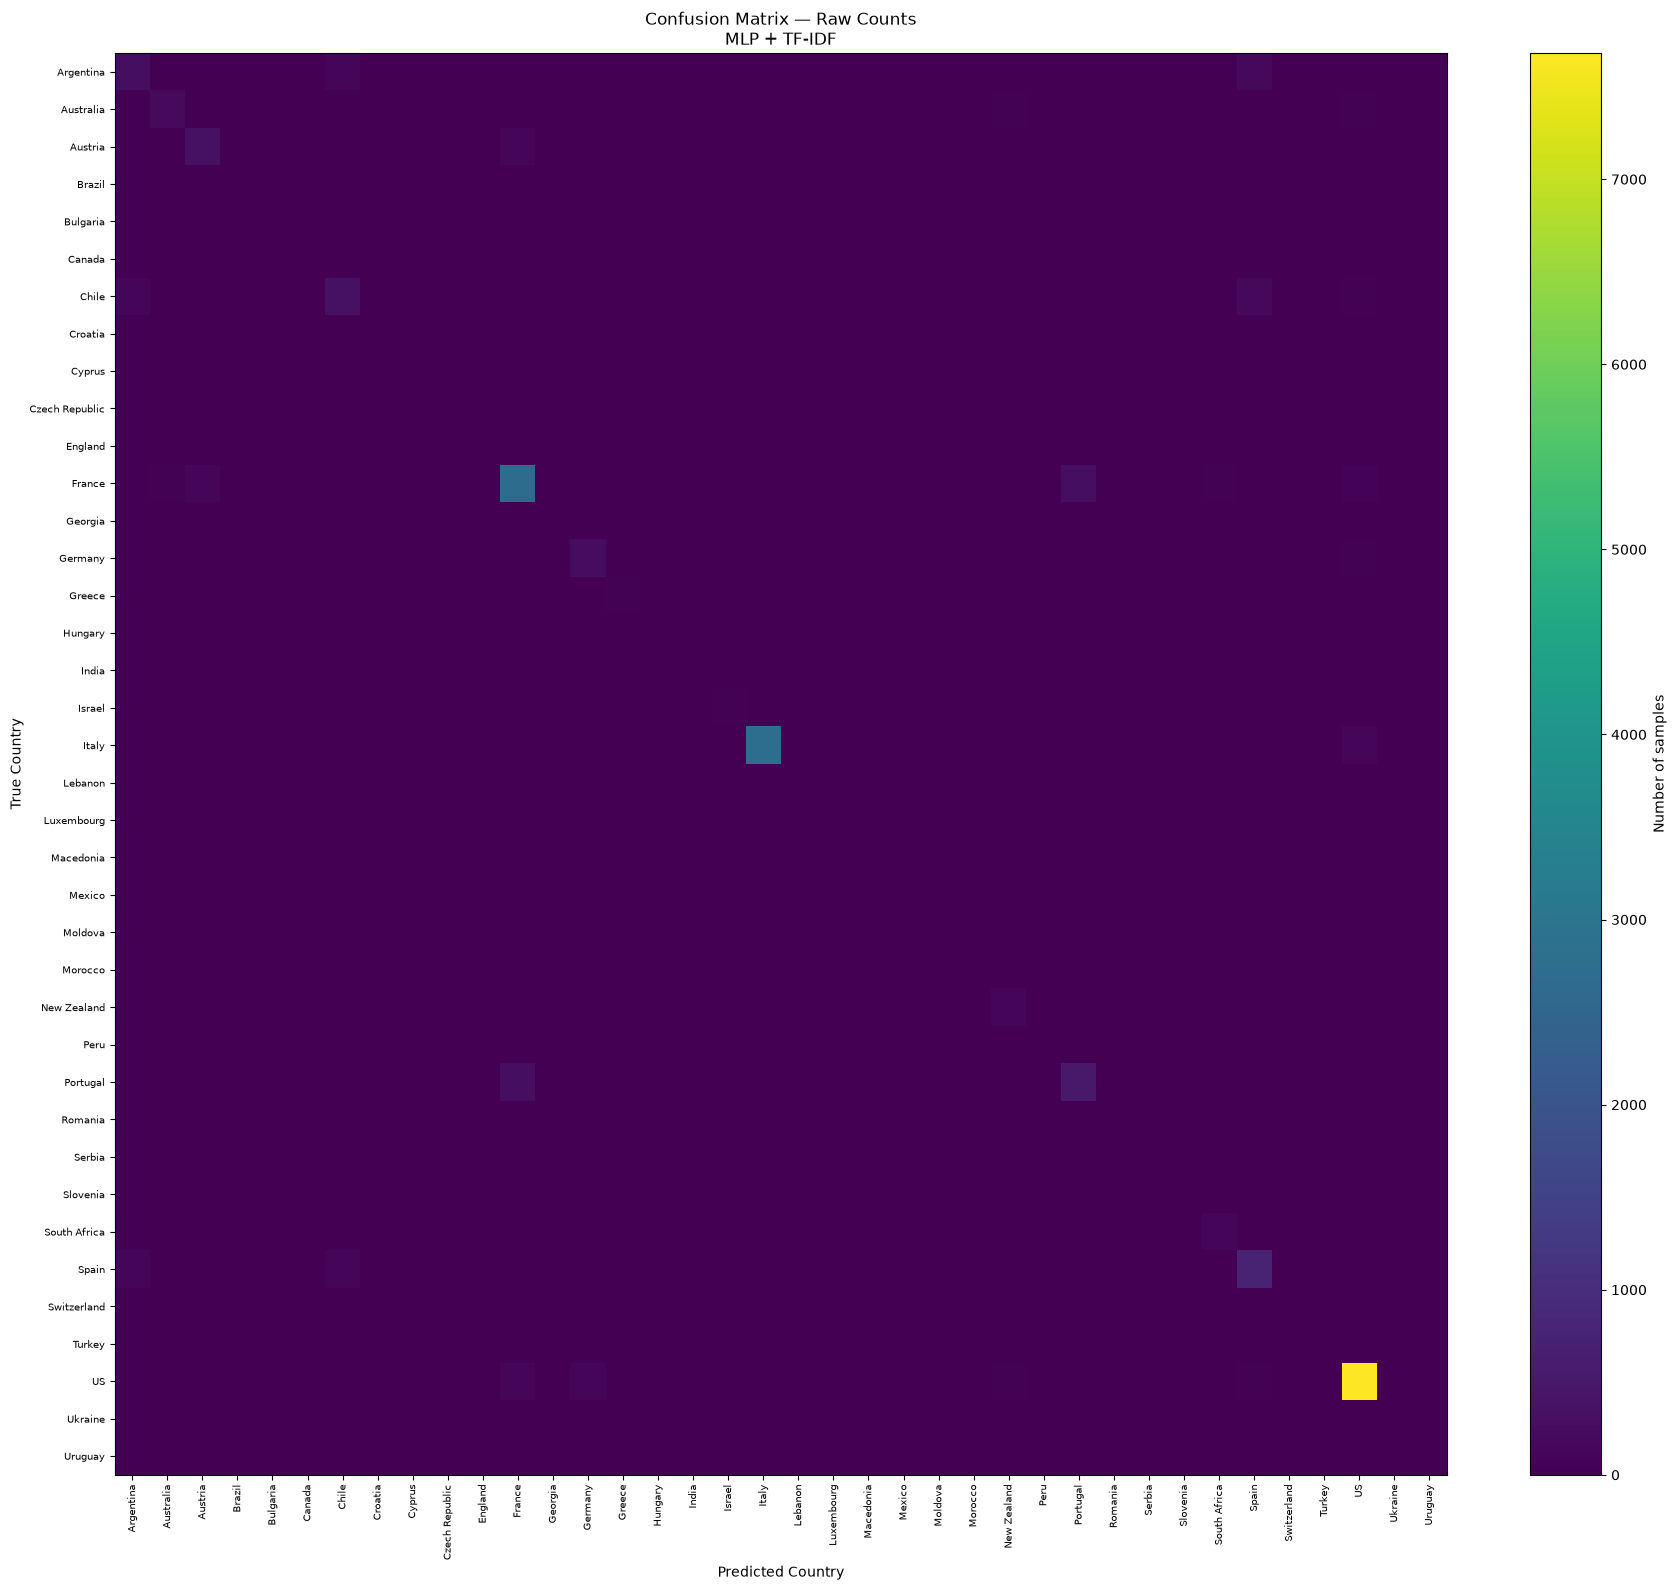

In [12]:
labels = np.arange(n_classes)
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(18, 16))
im = ax.imshow(cm, aspect="auto")

ax.set_title("Confusion Matrix — Raw Counts\nMLP + TF-IDF")
ax.set_xlabel("Predicted Country")
ax.set_ylabel("True Country")

ax.set_xticks(labels)
ax.set_yticks(labels)
ax.set_xticklabels(class_names, rotation=90, fontsize=7)
ax.set_yticklabels(class_names, fontsize=7)

fig.colorbar(im, ax=ax, label="Number of samples")
fig.tight_layout()
plt.show()

The confusion matrix shows that most correct predictions were concentrated among the larger classes, particularly the US, Italy, and France, as indicated by the stronger diagonal values. Misclassifications were more common among less represented countries, while some countries had very few or no correct predictions. This supports the earlier results, showing that class imbalance influenced the model towards the more frequently represented countries.

## Confusion matrix — row-normalized percentages

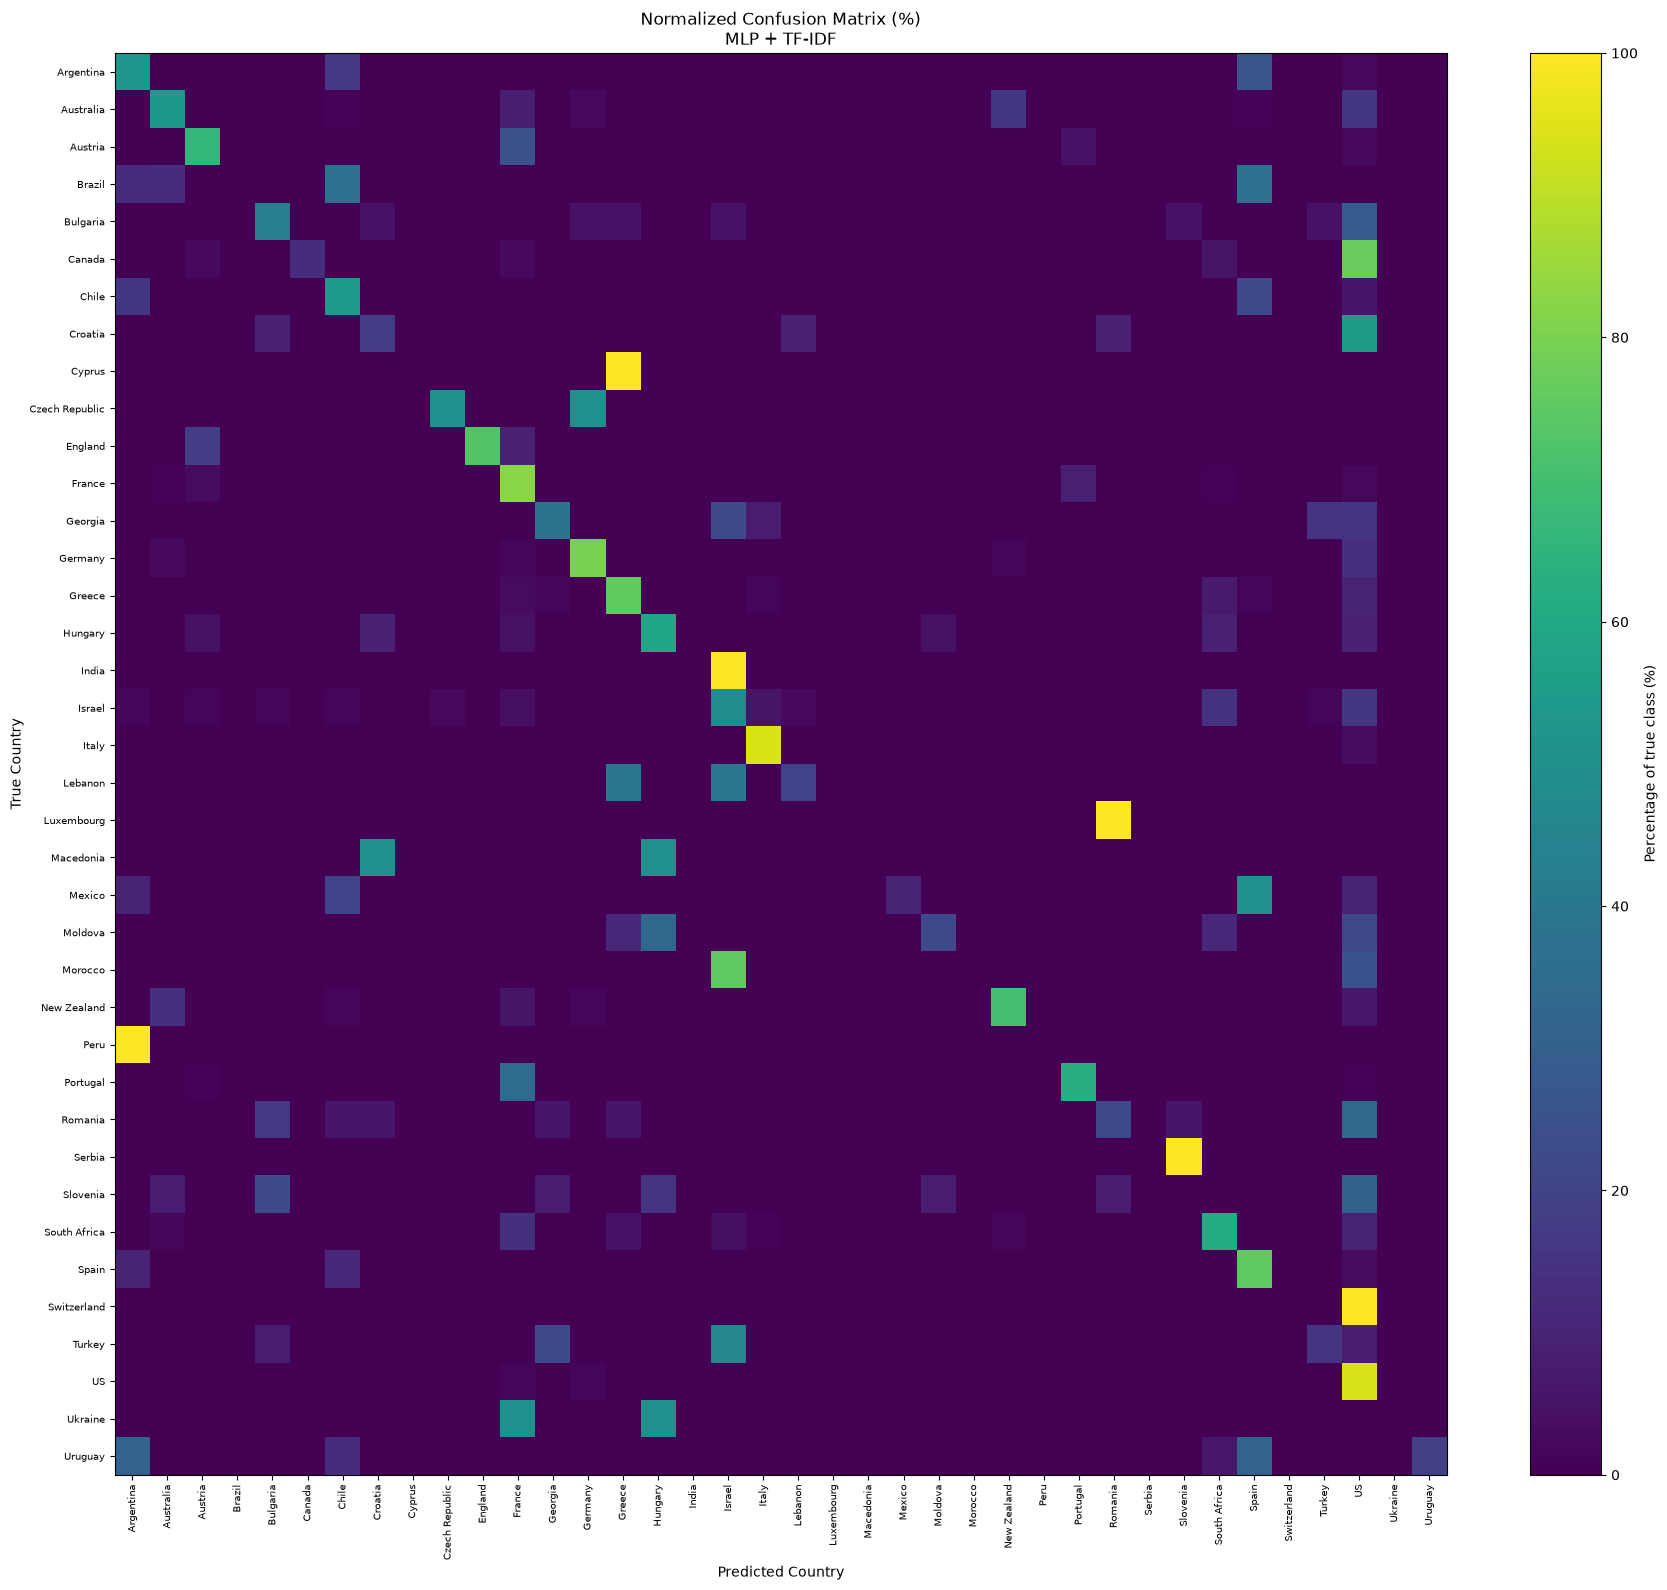

In [13]:
row_sums = cm.sum(axis=1, keepdims=True)
cm_percent = np.divide(
    cm,
    row_sums,
    out=np.zeros_like(cm, dtype=float),
    where=row_sums != 0,
) * 100

fig, ax = plt.subplots(figsize=(18, 16))
im = ax.imshow(cm_percent, aspect="auto", vmin=0, vmax=100)

ax.set_title("Normalized Confusion Matrix (%)\nMLP + TF-IDF")
ax.set_xlabel("Predicted Country")
ax.set_ylabel("True Country")

ax.set_xticks(labels)
ax.set_yticks(labels)
ax.set_xticklabels(class_names, rotation=90, fontsize=7)
ax.set_yticklabels(class_names, fontsize=7)

fig.colorbar(im, ax=ax, label="Percentage of true class (%)")
fig.tight_layout()
plt.show()

The normalized confusion matrix shows the model’s performance more clearly across countries regardless of sample size. Strong diagonal values for countries such as Italy, the US, France, Germany, and Spain indicate that a high proportion of their wines were correctly classified. In contrast, several smaller classes show weak or absent diagonal values and greater misclassification into other countries. This confirms that model performance varied considerably between countries.

## Most frequent country confusions

In [14]:
confusion_rows = []

for true_id in range(n_classes):
    for pred_id in range(n_classes):
        if true_id == pred_id:
            continue

        count = int(cm[true_id, pred_id])
        if count == 0:
            continue

        true_total = int(cm[true_id].sum())
        confusion_rows.append({
            "true_country": class_names[true_id],
            "predicted_country": class_names[pred_id],
            "count": count,
            "pct_of_true_country": 100 * count / true_total if true_total else 0,
        })

confusions_df = pd.DataFrame(confusion_rows).sort_values(
    ["count", "pct_of_true_country"],
    ascending=False,
)

display(confusions_df.head(25))
confusions_df.to_csv(OUTPUT_DIR / "country_confusions.csv", index=False)

,true_country,predicted_country,count,pct_of_true_country
154,Portugal,France,299,35.011710
71,France,Portugal,287,8.660229
50,Chile,Spain,156,23.248882
7,Argentina,Spain,151,26.491228
207,US,Germany,126,1.541096
23,Austria,France,124,24.701195
205,US,France,116,1.418787
186,Spain,Chile,111,11.133400
44,Chile,Argentina,108,16.095380
125,Italy,US,100,3.411805


The most frequent misclassification was Portugal as France, accounting for $35.0\%$ of Portuguese samples, followed by Argentina as Spain $(26.5%)$ and Austria as France $(24.7\%)$. Regional patterns were also visible, with confusion between Chile, Argentina, and Spain, as well as Australia and New Zealand. This suggests that reviews from countries with similar wine styles or terminology may contain overlapping language, making them more difficult for the model to distinguish.

## Multiclass ROC curves

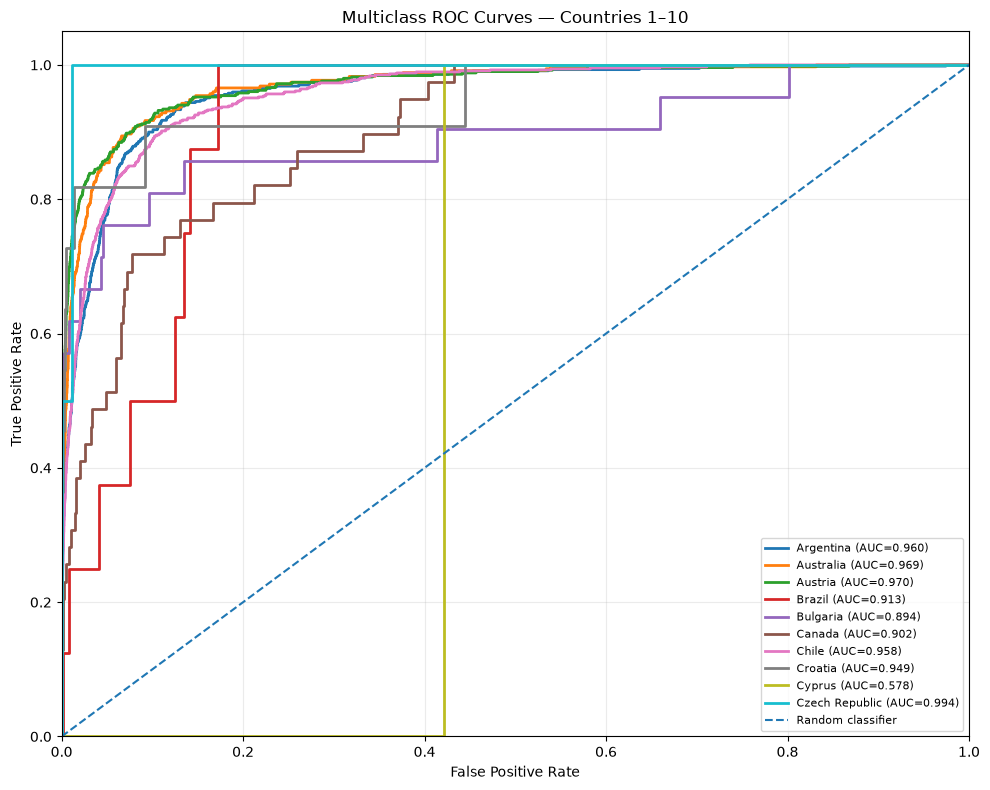

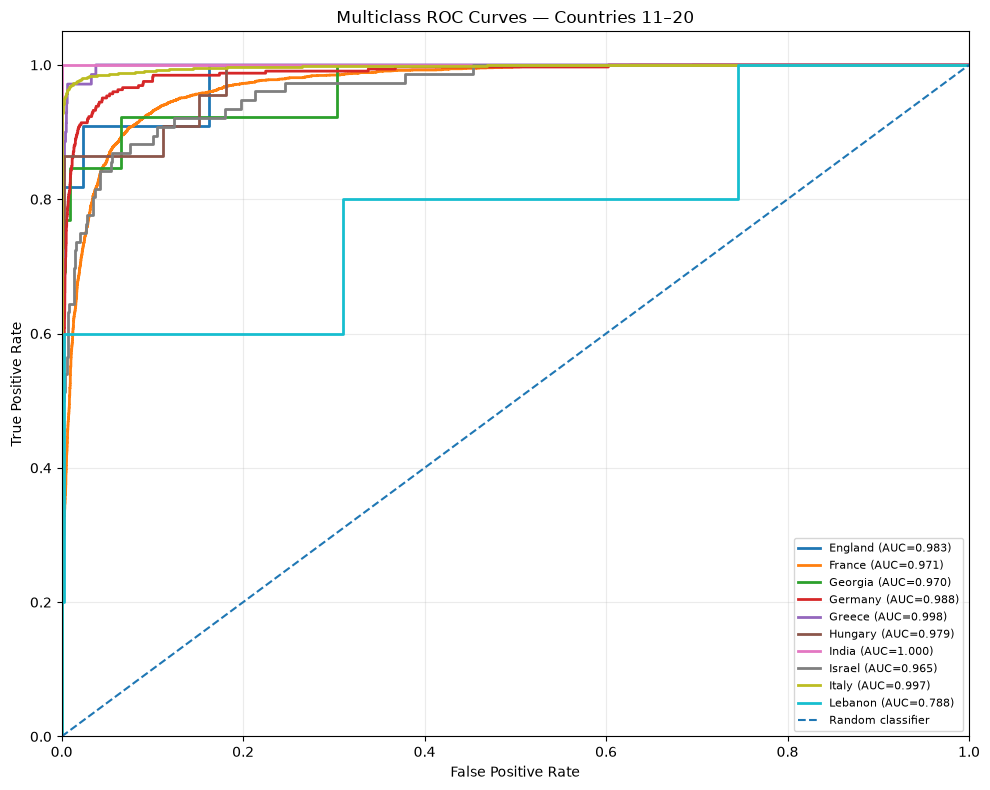

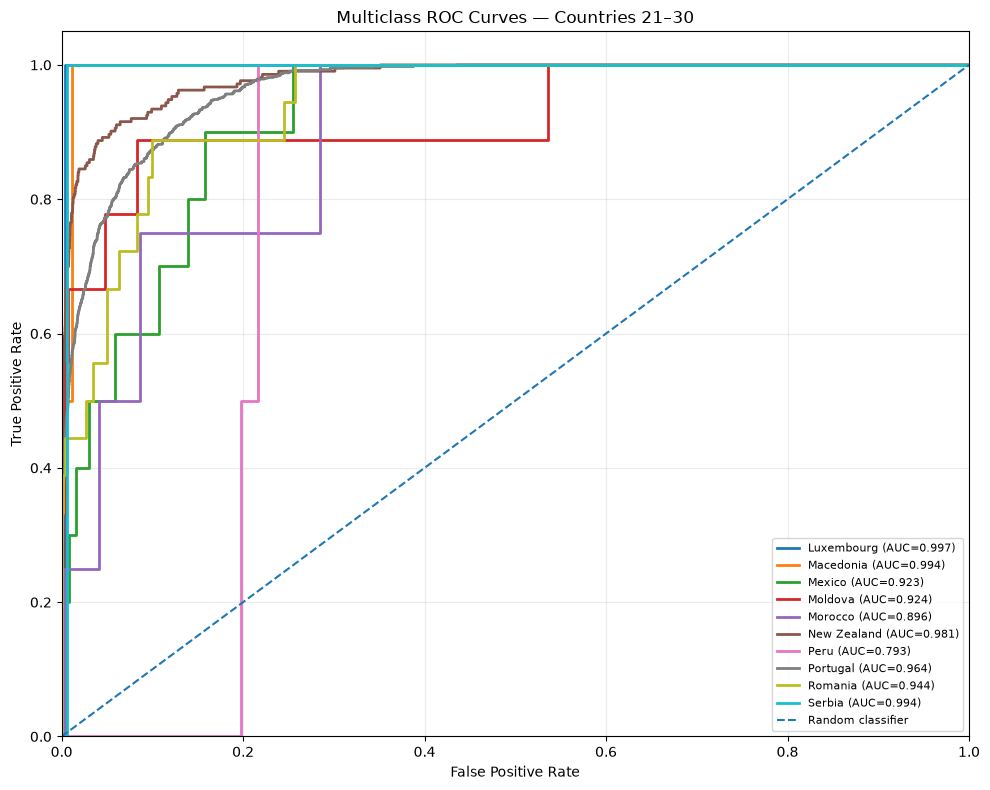

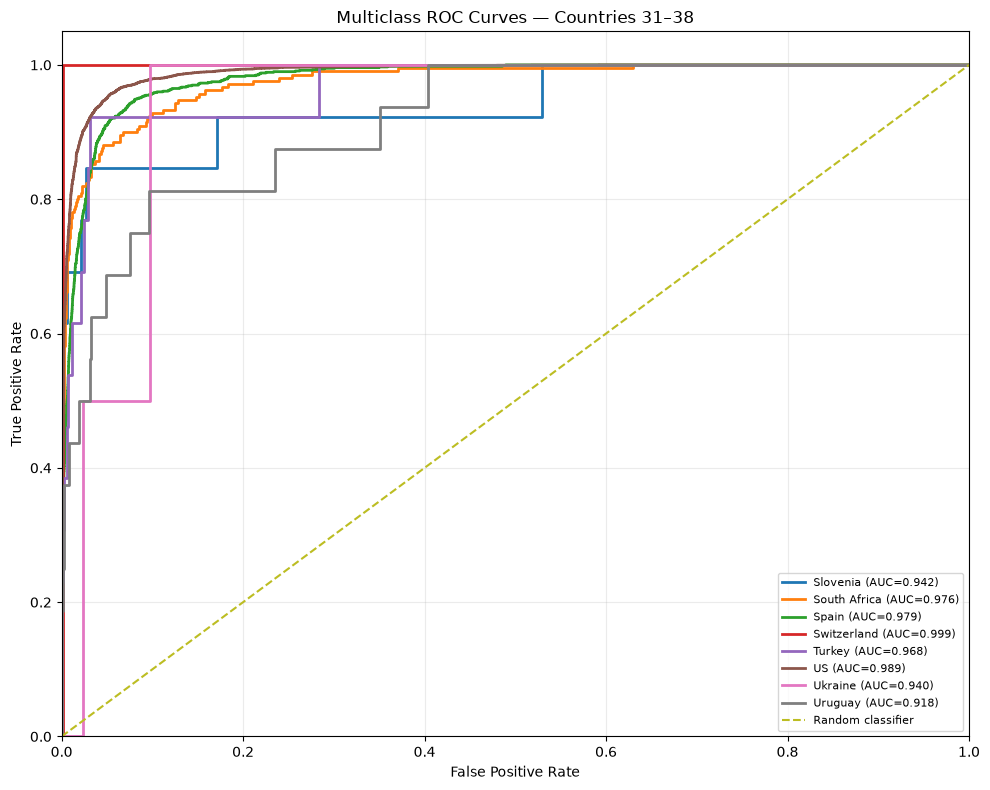

,country,roc_auc_ovr
8,Cyprus,0.578394
19,Lebanon,0.788101
26,Peru,0.793112
4,Bulgaria,0.893902
24,Morocco,0.896456
5,Canada,0.902090
3,Brazil,0.912639
37,Uruguay,0.918304
22,Mexico,0.922530
23,Moldova,0.924002


In [15]:
y_test_bin = label_binarize(y_true, classes=np.arange(n_classes))

fpr = {}
tpr = {}
roc_auc_by_class = {}

for i in range(n_classes):
    positives = y_test_bin[:, i].sum()
    negatives = len(y_test_bin) - positives

    if positives == 0 or negatives == 0:
        continue

    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc_by_class[i] = auc(fpr[i], tpr[i])

countries_per_graph = 10

for start in range(0, n_classes, countries_per_graph):
    end = min(start + countries_per_graph, n_classes)

    fig, ax = plt.subplots(figsize=(10, 8))

    plotted = 0
    for i in range(start, end):
        if i not in roc_auc_by_class:
            continue

        ax.plot(
            fpr[i],
            tpr[i],
            lw=2,
            label=f"{class_names[i]} (AUC={roc_auc_by_class[i]:.3f})",
        )
        plotted += 1

    ax.plot([0, 1], [0, 1], linestyle="--", lw=1.5, label="Random classifier")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"Multiclass ROC Curves — Countries {start + 1}–{end}")
    ax.grid(True, alpha=0.25)

    if plotted:
        ax.legend(loc="lower right", fontsize=8)

    fig.tight_layout()
    plt.show()

roc_auc_df = pd.DataFrame({
    "country": [class_names[i] for i in roc_auc_by_class],
    "roc_auc_ovr": [roc_auc_by_class[i] for i in roc_auc_by_class],
}).sort_values("roc_auc_ovr")

display(roc_auc_df)
roc_auc_df.to_csv(OUTPUT_DIR / "per_country_roc_auc.csv", index=False)

The ROC results indicate strong overall class-separation ability, with most countries achieving AUC values above $0.90$ and a macro ROC-AUC of $0.9433$. Italy $(0.997)$, the US $(0.989)$, and Germany $(0.988)$ showed particularly strong discrimination, while Cyprus had the lowest AUC at $0.578$. Some countries with very high AUC but low F1-scores also show that good ranking/separation does not necessarily result in correct final classifications, especially for classes with very few samples.

## Prediction-level results

In [16]:
confidence = y_prob.max(axis=1)
true_probability = y_prob[np.arange(len(y_true)), y_true]

prediction_df = pd.DataFrame({
    "clean_description": X_test.reset_index(drop=True),
    "true_id": y_true,
    "true_country": label_encoder.inverse_transform(y_true),
    "predicted_id": y_pred,
    "predicted_country": label_encoder.inverse_transform(y_pred),
    "confidence": confidence,
    "true_class_probability": true_probability,
    "correct": y_true == y_pred,
})

display(prediction_df.head())
prediction_df.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

,clean_description,true_id,true_country,predicted_id,predicted_country,confidence,true_class_probability,correct
0,initially dominate tannin this wine now evolve...,11,France,11,France,0.999812,0.999812,True
1,this wine successfully embody the tropical fru...,25,New Zealand,25,New Zealand,1.000000,1.000000,True
2,dry apricot citrus and brown sugar aroma provi...,35,US,35,US,0.997885,0.997885,True
3,standout amidst stellar lineup 2013 rheingau a...,13,Germany,13,Germany,0.999981,0.999981,True
4,very ripe yellow plum immediately temper zesty...,2,Austria,2,Austria,1.000000,1.000000,True


## Error analysis

In [17]:
errors_df = (
    prediction_df.loc[~prediction_df["correct"]]
    .sort_values("confidence", ascending=False)
    .reset_index(drop=True)
)

print(f"Total errors: {len(errors_df):,}")
print(f"Error rate: {len(errors_df) / len(prediction_df):.2%}")

display(
    errors_df[
        [
            "true_country",
            "predicted_country",
            "confidence",
            "true_class_probability",
            "clean_description",
        ]
    ].head(30)
)

errors_df.to_csv(OUTPUT_DIR / "misclassified_reviews.csv", index=False)

Total errors: 3,165
Error rate: 16.24%


,true_country,predicted_country,confidence,true_class_probability,clean_description
0,Chile,Argentina,1.000000,1.421159e-08,earthy plum and berry aroma come with hint rub...
1,Chile,Argentina,1.000000,6.307427e-08,you know falernia and elqui then this fit the ...
2,Argentina,Spain,1.000000,1.269330e-07,leather berry earth raisin and roasted quality...
3,Argentina,Uruguay,1.000000,6.901711e-12,strain jumbled aroma mustard horseradish and g...
4,Cyprus,Greece,0.999999,2.622815e-07,this cretan indigenous white offer aroma toast...
5,Argentina,Spain,0.999999,3.809343e-08,peach pit and stone fruit aroma dry and touch ...
6,Austria,France,0.999999,2.430157e-07,distinct dried pear apricot and sultana note s...
7,US,Germany,0.999999,1.151647e-06,slick wax and lanolin lend mineral tone bright...
8,Argentina,Chile,0.999999,1.576459e-08,lime and green melon aroma bit less than clean...
9,Argentina,Chile,0.999999,1.576459e-08,lime and green melon aroma bit less than clean...


The error analysis identified $3,165$ incorrect predictions, giving an error rate of $16.24\%$. Several errors were made with extremely high confidence, including confusion between Chile and Argentina, Argentina and Spain, and Portugal and France. This suggests that the model sometimes strongly associates similar review vocabulary with the wrong country, indicating that its confidence scores may not always reflect prediction reliability.

## Confidence analysis

In [18]:
confidence_bins = np.linspace(0.0, 1.0, 11)

confidence_df = prediction_df.copy()
confidence_df["confidence_bin"] = pd.cut(
    confidence_df["confidence"],
    bins=confidence_bins,
    include_lowest=True,
)

confidence_summary = (
    confidence_df.groupby("confidence_bin", observed=False)
    .agg(
        samples=("correct", "size"),
        accuracy=("correct", "mean"),
        mean_confidence=("confidence", "mean"),
    )
    .reset_index()
)

display(
    confidence_summary.style.format({
        "accuracy": "{:.4f}",
        "mean_confidence": "{:.4f}",
    })
)

confidence_summary.to_csv(
    OUTPUT_DIR / "confidence_by_bin.csv",
    index=False,
)

,confidence_bin,samples,accuracy,mean_confidence
0,"(-0.001, 0.1]",0,nan,nan
1,"(0.1, 0.2]",1,0.0000,0.1811
2,"(0.2, 0.3]",9,0.3333,0.2651
3,"(0.3, 0.4]",68,0.1765,0.3618
4,"(0.4, 0.5]",162,0.2901,0.4620
5,"(0.5, 0.6]",490,0.4245,0.5493
6,"(0.6, 0.7]",493,0.4239,0.6501
7,"(0.7, 0.8]",616,0.5325,0.7520
8,"(0.8, 0.9]",824,0.5109,0.8539
9,"(0.9, 1.0]",16823,0.8972,0.9935


The confidence analysis shows that higher model confidence generally corresponded with greater accuracy. Most predictions $(16,823)$ fell within the $0.9–1.0$ confidence range and achieved $89.72\%$ accuracy. However, their mean confidence was $99.35\%$, indicating that the model was somewhat overconfident, as its confidence was higher than its actual accuracy.

## Reliability plot

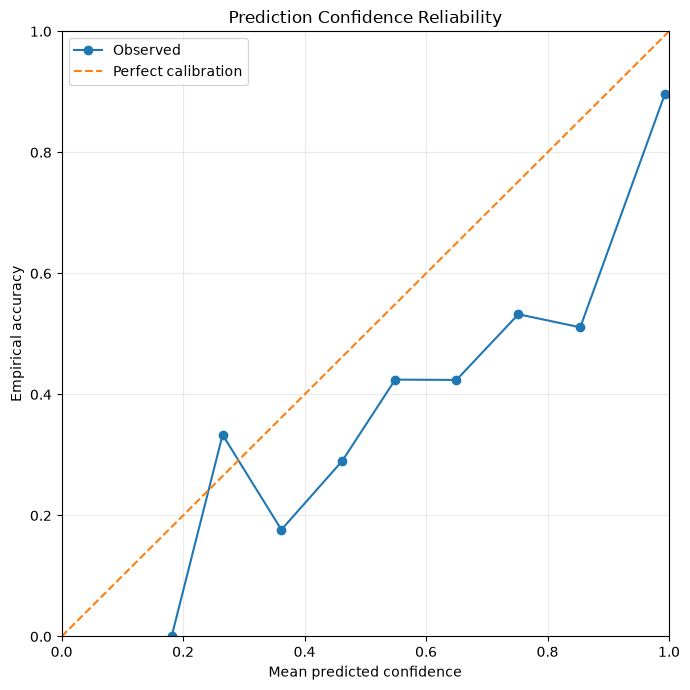

In [19]:
plot_df = confidence_summary.dropna(
    subset=["accuracy", "mean_confidence"]
)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(
    plot_df["mean_confidence"],
    plot_df["accuracy"],
    marker="o",
    label="Observed",
)
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration",
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Mean predicted confidence")
ax.set_ylabel("Empirical accuracy")
ax.set_title("Prediction Confidence Reliability")
ax.grid(True, alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

The reliability curve confirms that the model is generally **overconfident**, as the observed accuracy lies below the perfect-calibration line for most confidence levels. This is especially noticeable for predictions with high confidence, where predicted confidence exceeds actual accuracy. Therefore, although the model achieves strong overall performance, its probability estimates should be interpreted cautiously.

## Accuracy at different confidence thresholds

In [20]:
threshold_rows = []

for threshold in np.arange(0.0, 1.0, 0.1):
    keep = prediction_df["confidence"] >= threshold
    count = int(keep.sum())

    threshold_rows.append({
        "minimum_confidence": threshold,
        "samples_retained": count,
        "coverage": count / len(prediction_df),
        "accuracy": (
            prediction_df.loc[keep, "correct"].mean()
            if count > 0 else np.nan
        ),
    })

threshold_df = pd.DataFrame(threshold_rows)

display(
    threshold_df.style.format({
        "minimum_confidence": "{:.1f}",
        "coverage": "{:.2%}",
        "accuracy": "{:.4f}",
    })
)

threshold_df.to_csv(
    OUTPUT_DIR / "confidence_thresholds.csv",
    index=False,
)

,minimum_confidence,samples_retained,coverage,accuracy
0,0.0,19486,100.00%,0.8376
1,0.1,19486,100.00%,0.8376
2,0.2,19485,99.99%,0.8376
3,0.3,19476,99.95%,0.8379
4,0.4,19408,99.60%,0.8402
5,0.5,19246,98.77%,0.8448
6,0.6,18756,96.25%,0.8558
7,0.7,18263,93.72%,0.8674
8,0.8,17647,90.56%,0.8791
9,0.9,16823,86.33%,0.8972


The confidence threshold analysis shows a clear trade-off between coverage and accuracy. Using all predictions achieved $83.76\%$ accuracy, while restricting predictions to confidence scores of at least $0.9$ increased accuracy to $89.72\%$ but reduced coverage to $86.33\%$. This suggests that confidence thresholds can improve prediction reliability by excluding less certain classifications.

## Per-country support vs. F1

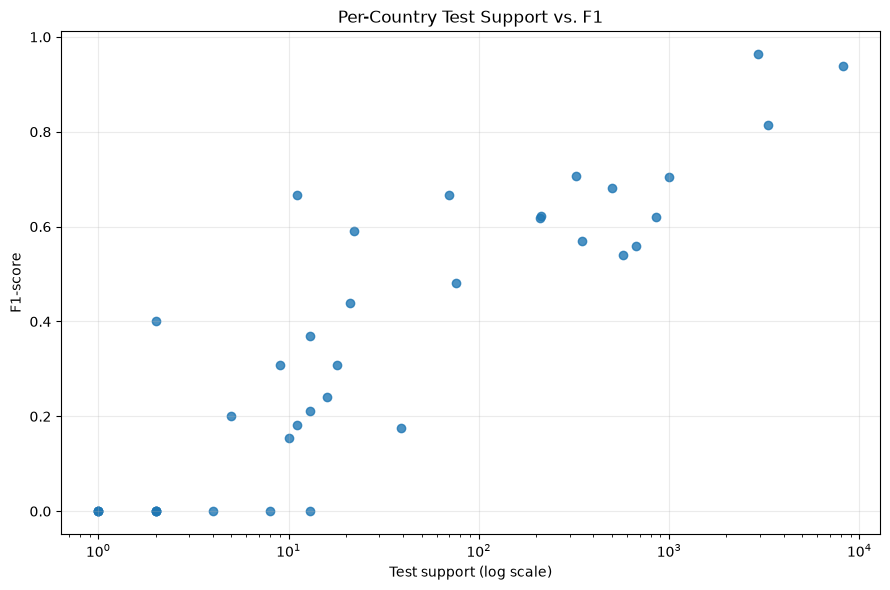

In [21]:
support_f1_df = (
    country_report_df.reset_index()
    [["country", "support", "f1-score"]]
    .sort_values("support")
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    support_f1_df["support"],
    support_f1_df["f1-score"],
    alpha=0.8,
)

ax.set_xscale("log")
ax.set_xlabel("Test support (log scale)")
ax.set_ylabel("F1-score")
ax.set_title("Per-Country Test Support vs. F1")
ax.grid(True, alpha=0.25)

fig.tight_layout()
plt.show()

The plot shows a general positive relationship between the number of test samples and F1-score. Countries with greater support tend to achieve higher F1-scores, while countries with very few samples show lower and more variable performance. This provides further evidence that **class imbalance affects the model’s ability to classify less-represented countries reliably**.

## Save an evaluation summary

In [22]:
summary = {
    "model_path": str(MODEL_PATH),
    "test_path": str(TEST_PATH),
    "train_path": str(TRAIN_PATH),
    "vectorizer_source": (
        "rebuilt_from_train1.csv"
        if REBUILD_VECTORIZER_FROM_TRAIN
        else str(VECTORIZER_PATH)
    ),
    "test_samples": int(len(y_true)),
    "n_classes": int(n_classes),
    "input_dim": int(input_dim),
    "hidden_dims": hidden_dims,
    "dropout": dropout,
    "best_params": best_params,
    "metrics": {
        key: (None if pd.isna(value) else float(value))
        for key, value in metrics.items()
    },
}

with open(OUTPUT_DIR / "evaluation_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(f"Saved evaluation outputs to: {OUTPUT_DIR.resolve()}")
print("\nFiles:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path.name)

Saved evaluation outputs to: /home/jupyter/evaluation_outputs

Files:
 - confidence_by_bin.csv
 - confidence_thresholds.csv
 - country_confusions.csv
 - evaluation_summary.json
 - misclassified_reviews.csv
 - overall_metrics.csv
 - per_country_classification_report.csv
 - per_country_roc_auc.csv
 - test_predictions.csv


## Final evaluation summary

In [23]:
print("=" * 65)
print("FINAL TEST EVALUATION — MLP + TF-IDF")
print("=" * 65)
print(f"Test samples:              {len(y_true):,}")
print(f"Countries/classes:         {n_classes}")
print(f"Accuracy:                  {metrics['accuracy']:.4f}")
print(f"Macro F1:                  {metrics['f1_macro']:.4f}")
print(f"Weighted F1:               {metrics['f1_weighted']:.4f}")
print(f"Macro Precision:           {metrics['precision_macro']:.4f}")
print(f"Macro Recall:              {metrics['recall_macro']:.4f}")
print(f"Weighted Precision:        {metrics['precision_weighted']:.4f}")
print(f"Weighted Recall:           {metrics['recall_weighted']:.4f}")

if not pd.isna(metrics["roc_auc_macro_ovr"]):
    print(f"Macro ROC-AUC (OvR):       {metrics['roc_auc_macro_ovr']:.4f}")
if not pd.isna(metrics["roc_auc_weighted_ovr"]):
    print(f"Weighted ROC-AUC (OvR):    {metrics['roc_auc_weighted_ovr']:.4f}")

print("=" * 65)

worst = country_report_df.head(5)
best = country_report_df.tail(5).sort_values("f1-score", ascending=False)

print("\nFive lowest-F1 countries:")
for country, row in worst.iterrows():
    print(
        f"  {country:20s} "
        f"F1={row['f1-score']:.4f} "
        f"(support={int(row['support'])})"
    )

print("\nFive highest-F1 countries:")
for country, row in best.iterrows():
    print(
        f"  {country:20s} "
        f"F1={row['f1-score']:.4f} "
        f"(support={int(row['support'])})"
    )

FINAL TEST EVALUATION — MLP + TF-IDF
Test samples:              19,486
Countries/classes:         38
Accuracy:                  0.8376
Macro F1:                  0.3614
Weighted F1:               0.8367
Macro Precision:           0.3779
Macro Recall:              0.3612
Weighted Precision:        0.8374
Weighted Recall:           0.8376
Macro ROC-AUC (OvR):       0.9433
Weighted ROC-AUC (OvR):    0.9818

Five lowest-F1 countries:
  Slovenia             F1=0.0000 (support=13)
  Brazil               F1=0.0000 (support=8)
  Morocco              F1=0.0000 (support=4)
  Macedonia            F1=0.0000 (support=2)
  Peru                 F1=0.0000 (support=2)

Five highest-F1 countries:
  Italy                F1=0.9643 (support=2931)
  US                   F1=0.9397 (support=8176)
  France               F1=0.8148 (support=3314)
  Germany              F1=0.7077 (support=325)
  Spain                F1=0.7036 (support=997)


### Model Evaluation Summary

* **Overall performance:** The MLP + TF-IDF model was evaluated on **19,486 wine reviews across 38 countries**. It achieved an overall **accuracy of 83.76%**, meaning that the model correctly predicted the country of origin for approximately 84% of the test reviews. The **weighted F1-score of 0.8367** was similarly strong, showing good overall classification performance.

* **Effect of class imbalance:** Despite the high overall accuracy, the **macro F1-score was only 0.3614**, with macro precision and recall of **0.3779 and 0.3612**, respectively. The large difference between the macro and weighted scores indicates that performance was uneven across countries. The weighted metrics are dominated by countries with many samples, whereas the macro metrics give equal importance to every country. This suggests that the strong overall results are mainly driven by the model's performance on the larger classes.

* **Best-performing countries:** The highest F1-scores were achieved for **Italy (0.9643), the US (0.9397), France (0.8148), Germany (0.7077), and Spain (0.7036)**. Italy, the US, and France also had some of the largest test supports, with 2,931, 8,176, and 3,314 samples respectively. The support-versus-F1 analysis showed a general positive relationship between the number of available samples and classification performance.

* **Lowest-performing countries:** Several underrepresented countries performed poorly. **Slovenia, Brazil, Morocco, Macedonia, and Peru** all had F1-scores of **0**, with only 2–13 test samples each. This means the model was unable to correctly identify these classes in the test set. However, sample size was not the only factor affecting performance, as some countries with relatively few samples still achieved reasonable F1-scores.

* **Country confusion:** The confusion matrices showed that correct predictions were concentrated around the larger and better-performing classes. Some clear patterns of confusion were observed between countries. For example, **35.0% of Portuguese wines were predicted as French**, while **26.5% of Argentine wines were predicted as Spanish** and **24.7% of Austrian wines were predicted as French**. Confusion was also observed between Chile, Argentina and Spain, as well as Australia and New Zealand, suggesting that reviews from these countries may contain similar wine descriptions or terminology.

* **ROC-AUC performance:** The model achieved a high **macro ROC-AUC of 0.9433** and **weighted ROC-AUC of 0.9818**, indicating strong overall ability to distinguish between country classes. However, high ROC-AUC did not always correspond to high F1-scores. Some countries with very few samples had high AUC values but poor F1 performance, showing that the model could rank classes reasonably well without necessarily selecting the correct class as its final prediction.

* **Error analysis:** The model made **3,165 incorrect predictions**, corresponding to an **error rate of 16.24%**. Importantly, some incorrect classifications were made with confidence scores close to 100%. This shows that the model can occasionally be highly confident in an incorrect country prediction, particularly where countries share similar review characteristics.

* **Confidence and calibration:** Higher-confidence predictions were generally more accurate, but the model showed signs of **overconfidence**. Predictions with confidence between 0.9 and 1.0 had a mean confidence of **99.35%**, but their actual accuracy was **89.72%**. The reliability curve also showed observed accuracy falling below predicted confidence across most confidence levels, indicating that the probability estimates are not perfectly calibrated.

* **Confidence threshold trade-off:** Applying a minimum confidence threshold improved accuracy at the cost of reducing the number of predictions retained. Without a threshold, accuracy was **83.76% with 100% coverage**. At a confidence threshold of 0.8, accuracy increased to **87.91% with 90.56% coverage**, while a threshold of 0.9 increased accuracy further to **89.72% with 86.33% coverage**. Therefore, confidence thresholds could be useful when prediction reliability is more important than classifying every review.

* **Overall conclusion:** The MLP + TF-IDF model provides **strong overall country classification performance**, particularly for countries that are well represented in the dataset. However, the low macro F1-score, poor minority-class performance, and support-versus-F1 relationship demonstrate that **class imbalance is a major limitation**. The model also shows some overconfidence in its predictions. Future improvements could therefore focus on addressing class imbalance and improving probability calibration to produce more consistent performance across all 38 countries.